In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import savgol_filter

# test data
# pressure = np.array([0.1, 0.4, 0.8, 1.6, 3.2, 6.4, 12.8, 3.2, 0.8], dtype=float)
# void_ratio = np.array([0.258, 0.254, 0.251, 0.239, 0.207, 0.182, 0.157, 0.17, 0.176], dtype=float)

# pressure = np.array([0.01, 0.1, 0.5, 1, 2, 0.5, 1, 2, 4, 8.0], dtype=float)
# void_ratio = np.array([0.3551, 0.3524, 0.3412, 0.3294, 0.3177, 0.3225, 0.3206, 0.3162, 0.2982, 0.2796], dtype=float)

pressure = np.array([35, 70, 140, 280, 560, 1120, 2240], dtype=float)
void_ratio = np.array([0.828, 0.81, 0.79, 0.75, 0.70, 0.63, 0.56], dtype=float)

# pressure = np.array([0,6.18,12.36,24.81,49.52,99.05,198.19,396.38,792.77,1585.43,792.77,396.38,198.19,99.05,49.52,99.05,198.19,396.38,792.77,1585.43,3170.87,6341.83,3170.87,1585.43,792.77,396.38,198.19], dtype=float)
# void_ratio = np.array([0.775189516,0.759745368,0.746786484,0.730454741,0.709152466,0.684654851,0.656384958,0.616842612,0.573883025,0.512772126,0.519917264,0.532166072,0.548320296,0.566072191,0.586131833,0.579741151,0.566959786,0.548675334,0.528615693,0.499857622,0.441808925,0.375771875,0.378789697,0.391393543,0.40719273,0.426009739,0.446779456], dtype=float)

In [2]:
# utility functions

def loading_curve(x, y):
    """"
    This function takes pressure and void ratio and remove unloading-reloading cycles. 
    x : presure
    y : void ratio
    """
    loading_data = []
    max_p = -np.inf
    e0 = y[0]

    for i, (p, e) in enumerate(zip(x, y)):
        if p > max_p:
            log_p = np.log10(p)
            epsilon = (e0-e)/(1+e0)
            loading_data.append((i, p, log_p, e, epsilon))
            max_p = p

    return np.array(loading_data, dtype=[('idx', int), ('p', float), ('log_p', float), ('e', float), ('epsilon', float)])

def remove_loginf_rows(loading_data):
    """
    Remove inf resulted from log(0)
    """
    mask = np.isfinite(loading_data['log_p'])
    return loading_data[mask]

# cubic spline
def cubic_spline_profile(x_fit, y_fit, n_points=500):
    """
    Return a curvature profile
    """
    # x_fit = data['log_p']
    # y_fit = data['e']

    # Sort data for stability
    order = np.argsort(x_fit)
    x_fit = x_fit[order]
    y_fit = y_fit[order]
    
    cs = CubicSpline(x_fit, y_fit)

    x_dense = np.linspace(x_fit.min(), x_fit.max(), n_points)
    y_dense = cs(x_dense)
    dy = cs(x_dense, 1)
    d2y = cs(x_dense, 2)
    kappa = np.abs(d2y) / (1 + dy**2)**1.5
    
    return np.column_stack((x_dense, y_dense, dy, d2y, kappa))

def stable_kappa_x(x, kappa, top_fraction=0.1):
    threshold = kappa.max() * (1 - top_fraction)
    idx = np.where(kappa >= threshold)[0]

    if len(idx) == 0:
        return x[np.argmax(kappa)]
    # weighted average
    return np.average(x[idx], weights=kappa[idx])

def local_slope(xg, yg, x0, window=7):
    i = np.argmin(np.abs(xg - x0))

    i0 = max(0, i - window)
    i1 = min(len(xg), i + window)

    if i1 - i0 < 3:
        return (yg[i1-1] - yg[i0]) / (xg[i1-1] - xg[i0])
    
    p = np.polyfit(xg[i0:i1], yg[i0:i1], 1)
    return p[0]

def find_max_kappa(profile):
    i_max = np.argmax(profile[:, 4])

    max_x = profile[i_max, 0]  # x_dense (log_p)
    max_y = profile[i_max, 1]  # y_dense (e)
    max_dy = profile[i_max, 2] # dy (slope)
    max_kappa = profile[i_max, 4] # kappa

    return max_x, max_y, max_dy, max_kappa

def find_min_dy(profile):
    i_min = np.argmin(profile[:, 2])

    min_x = profile[i_min, 0]  # x_dense (log_p)
    min_y = profile[i_min, 1]  # y_dense (e)
    min_dy = profile[i_min, 2] # dy (slope) = maximum Cc
    min_kappa = profile[i_min, 4] # kappa

    return min_x, min_y, min_dy, min_kappa

def bisector_slope(m):
    bisec_dy = m / (1 + np.sqrt(1 + m**2))
    return bisec_dy

def casagrande_spline(data):
    # Extract plain arrays from structured input — avoids downstream string-indexing errors
    if data.dtype.names and 'log_p' in data.dtype.names:
        x_fit = data['log_p'].astype(float)
        y_fit = data['e'].astype(float)
    else:
        raise TypeError(
            "casagrande_spline expects a structured array with 'log_p' and 'e' fields. "
            "Pass the output of remove_loginf_rows(loading_curve(...))."
        )

    profile = cubic_spline_profile(x_fit, y_fit)   # plain arrays now
    xg = profile[:, 0]
    yg = profile[:, 1]
    dy = profile[:, 2]
    kappa = profile[:, 4]

    xk = stable_kappa_x(xg, kappa)
    yk = np.interp(xk, xg, yg)
    mk = local_slope(xg, yg, xk)

    mid = len(xg) // 3
    idx2 = int(np.argmin(dy[mid:]) + mid)   # explicit int cast guards against numpy scalar edge cases
    m2 = float(dy[idx2])
    x2 = float(xg[idx2])
    y2 = float(yg[idx2])

    m1 = bisector_slope(mk)

    if np.isclose(m1, m2, atol=1e-6):
        raise ValueError("Bisector and virgin compression line are nearly parallel — "
                         "check data range or spline quality.")
    x_int = (y2 - yk + m1 * xk - m2 * x2) / (m1 - m2)
    y_int = yk + m1 * (x_int - xk)
    return x_int, y_int

# Bilinear approach
def fit_error(x, y, deg=1):
    """
    General fitting function
    """
    coeff = np.polyfit(x, y, deg)
    y_pred = np.polyval(coeff, x)
    return np.sum((y - y_pred)**2)
    
def general_bilinear(x, y):
    """
    This function uses linear regression to find the 'break'.    
    """
    n = len(x)
    best_k   = None
    best_err = float('inf')

    for k in range(2, n - 1):        # right segment needs ≥ 2 points → k < n-1
        err1 = fit_error(x[:k], y[:k], 1)
        err2 = fit_error(x[k:], y[k:], 1)
        tot_err = err1 + err2
        if tot_err < best_err:
            best_err = tot_err
            best_k   = k

    # Refit both segments with best k to get the line coefficients
    coeff1 = np.polyfit(x[:best_k], y[:best_k], 1)
    coeff2 = np.polyfit(x[best_k:], y[best_k:], 1)

    dslope = coeff1[0] - coeff2[0]
    if np.isclose(dslope, 0, atol=1e-10):
        raise ValueError(
            "The two regression lines are nearly parallel. No reliable Pc can be found."
        )

    x_int = (coeff2[1] - coeff1[1]) / dslope
    y_int = np.polyval(coeff1, x_int)

    # Plotting parameters for each segment (extended to meet at intersection)
    x1 = np.append(x[:best_k], x_int)
    x2 = np.insert(x[best_k:], 0, x_int)
    seg1 = {"x": x1, "y_fit": np.polyval(coeff1, x1)}
    seg2 = {"x": x2, "y_fit": np.polyval(coeff2, x2)}

    return {
        "x_int": x_int, "y_int": y_int,
        "coeff1": coeff1, "coeff2": coeff2,
        "seg1": seg1, "seg2": seg2,
        "best_k": best_k,
    }

# Work strain energy
def work_strain_energy(sigma, epsilon):
    """
    Becker et al. (1987)
    """
    # epsilon
    dWork = 0.5 * (epsilon[1:] - epsilon[:-1]) * (sigma[1:] + sigma[:-1])
    dWork = np.hstack((0, dWork))
    
    return np.cumsum(dWork)


# Find break
def find_best_k(x, y):
    """
    This function uses linear regression to find the 'break'. 
    x is taken as log10(x).    
    """
    n = len(x)
    log_x = np.log10(x)
    best_k = None
    best_err = float('inf')
    err = []
    
    for k in range(2, n-2):
        err1 = fit_error(log_x[:k], y[:k], 1)
        err2 = fit_error(log_x[k:], y[k:], 1)

        tot_err = err1 + err2
        err.append(tot_err)

        if tot_err < best_err:
            best_err = tot_err
            best_k = k

    sigma_p = 10**log_x[best_k]
    e_p = y[best_k]

    return sigma_p, e_p, best_k

No handles with labels found to put in legend.


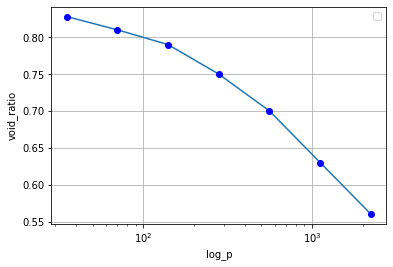

In [3]:
# plot data
res = loading_curve(pressure, void_ratio)
p_load = res['p']
log_p_load = res['log_p']
e_load = res['e']
epsilon_load = res['epsilon']
# sigma_p, e_p, best_k = find_sigma_p(p_load, e_load)

plt.plot(pressure, void_ratio)
plt.plot(p_load, e_load, "bo")
plt.xlabel("log_p")
plt.ylabel("void_ratio")
plt.xscale('log')
plt.legend()
plt.grid()

In [4]:
# Clean up data
res = remove_loginf_rows(res)
x = res['p']
log_x = res['log_p']
y = res['e']

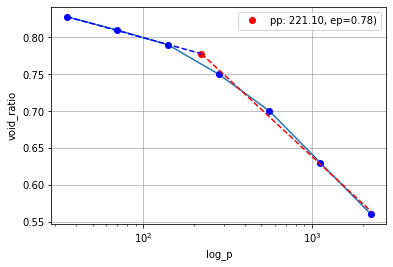

In [5]:
# bilinear: log_p vs. e
result = general_bilinear(log_x, y)

plt.plot(pressure, void_ratio)
plt.plot(p_load, e_load, "bo")
plt.plot(10**result["x_int"], result["y_int"], "ro", label=f'pp: {10**result["x_int"]:.2f}, ep={result["y_int"]:.2f})')
plt.plot(10**result["seg1"]["x"], result["seg1"]["y_fit"], "b--") # convereted from log10
plt.plot(10**result["seg2"]["x"], result["seg2"]["y_fit"], "r--") # convereted from log10
plt.xlabel("log_p")
plt.ylabel("void_ratio")
plt.xscale('log')
plt.legend()
plt.grid()

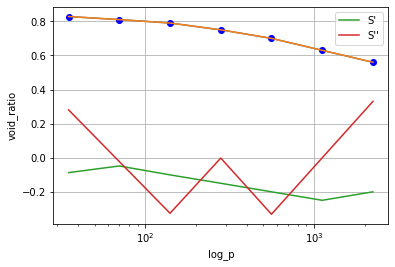

In [6]:
# Cubic spline sanity check
cs = CubicSpline(log_x, y)

plt.plot(pressure, void_ratio)
plt.plot(x, y, "bo")
plt.plot(x, cs(log_x))
plt.plot(x, cs(log_x, 1), label="S'")
plt.plot(x, cs(log_x, 2), label="S''")
plt.xlabel("log_p")
plt.ylabel("void_ratio")
plt.xscale('log')
plt.legend()
plt.grid()

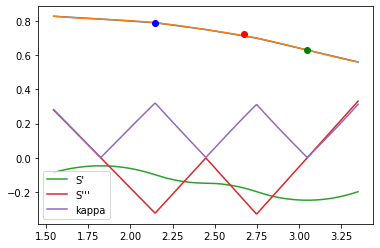

In [7]:
curve = cubic_spline_profile(res['log_p'], res['e'], n_points=500)
x = curve[:,0]
y = curve[:,1]
dy = curve[:,2]
d2y = curve[:,3]
kappa = curve[:,4]

max_x, max_y, max_dy, max_kappa = find_max_kappa(curve)
min_x, min_y, min_dy, min_kappa = find_min_dy(curve)
pp, ep = casagrande_spline(res)

plt.plot(np.log10(pressure), void_ratio)
plt.plot(x, y)
plt.plot(x, dy, label = "S'")
plt.plot(x, d2y, label="S'''")
plt.plot(x, kappa, label="kappa")
plt.plot(max_x, max_y, "bo")
plt.plot(min_x, min_y, "go")
plt.plot(pp, ep, "ro")
plt.legend()

In [8]:
# work strain energy
dWork = work_strain_energy(p_load, epsilon_load)
dWork

array([  0.        ,   0.51695842,   1.66575492,   6.26094092,
        17.74890591,  49.91520788, 114.24781182])

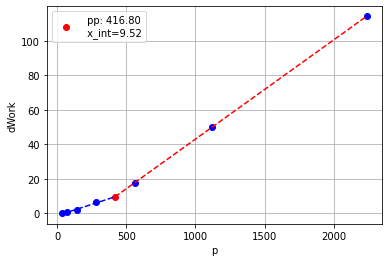

In [9]:
x = res['p']
result = general_bilinear(x, dWork)   # x = res['p']

plt.plot(x, dWork, "bo")
plt.plot(result["x_int"], result["y_int"], "ro", label=f' pp: {result["x_int"]:.2f}\n x_int={result["y_int"]:.2f}')
plt.plot(result["seg1"]["x"], result["seg1"]["y_fit"], "b--") # convereted from log10
plt.plot(result["seg2"]["x"], result["seg2"]["y_fit"], "r--") # convereted from log10
plt.xlabel("p")
plt.ylabel("dWork")
plt.legend()
plt.grid()